In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed.csv")
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(60000, 2)


,text,label
0,Reference Account Number XXXX VIN XXXX Per my ...,consumer_loans
1,My house was foreclosed on a XX/XX/2018 and th...,debt_collection
2,I noticed that you are reporting inaccurate da...,debt_collection
3,1. Alleged Name and Address of Creditor 2. Nam...,cards_and_accounts
4,I had fraud charges filed on 4 credit cards wi...,cards_and_accounts


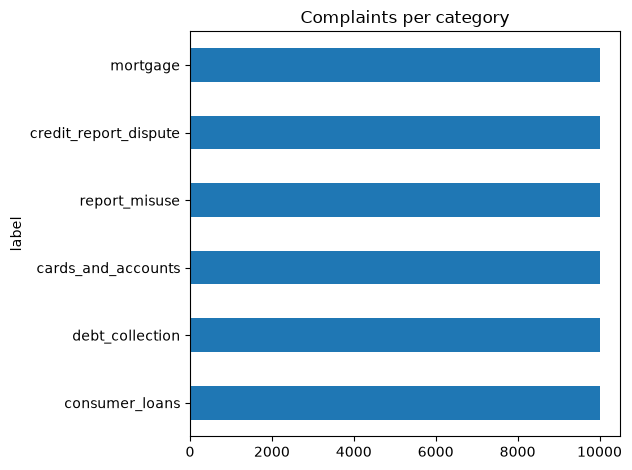

In [2]:
df["label"].value_counts().plot(kind="barh", title="Complaints per category")
plt.tight_layout()
plt.show()

count    60000.000000
mean       206.972283
std        226.417994
min          6.000000
50%        143.000000
90%        442.000000
95%        608.000000
max       6314.000000
Name: n_words, dtype: float64


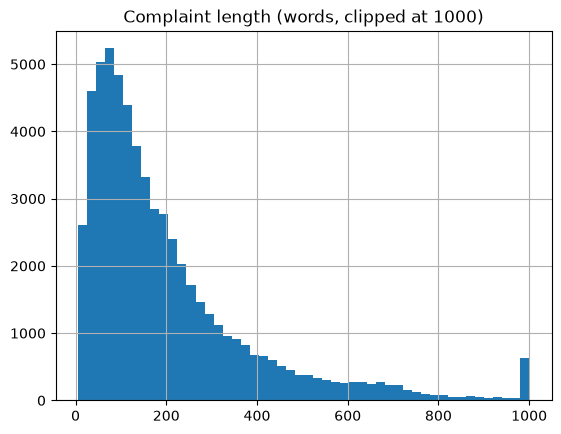

In [3]:
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe(percentiles=[0.5, 0.9, 0.95]))

df["n_words"].clip(upper=1000).hist(bins=50)
plt.title("Complaint length (words, clipped at 1000)")
plt.show()

In [4]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
sample = df["text"].sample(2000, random_state=42)
n_tokens = sample.map(lambda t: len(tok(t)["input_ids"]))
print(n_tokens.describe(percentiles=[0.5, 0.9, 0.95]))
print("Share longer than 256 tokens:", (n_tokens > 256).mean())

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1013 > 512). Running this sequence through the model will result in indexing errors


count    2000.000000
mean      269.529500
std       295.793793
min        11.000000
50%       183.500000
90%       579.100000
95%       782.200000
max      4345.000000
Name: text, dtype: float64
Share longer than 256 tokens: 0.358


In [5]:
df["redactions"] = df["text"].str.count(r"(?i)x{2,}")
print("Complaints with at least one XXXX:", (df["redactions"] > 0).mean())
print(df["redactions"].describe())

Complaints with at least one XXXX: 0.8651833333333333
count    60000.000000
mean        15.769917
std         33.641167
min          0.000000
25%          2.000000
50%          7.000000
75%         18.000000
max       1988.000000
Name: redactions, dtype: float64


In [6]:
import sys
sys.path.append("../src")
from preprocess import normalise
from sklearn.feature_extraction.text import TfidfVectorizer

clean = df["text"].map(normalise)
vec = TfidfVectorizer(stop_words="english", min_df=5, max_features=20000)
X = vec.fit_transform(clean)
words = vec.get_feature_names_out()

for label in sorted(df["label"].unique()):
    mask = (df["label"] == label).values
    scores = X[mask].mean(axis=0).A1
    top = words[scores.argsort()[::-1][:12]]
    print(f"{label:24s} {', '.join(top)}")

cards_and_accounts       account, card, bank, 00, credit, money, chase, told, payment, called, did, balance
consumer_loans           loan, loans, payment, navient, payments, 00, student, pay, told, account, time, month
credit_report_dispute    credit, report, account, reporting, information, accounts, equifax, experian, removed, reported, late, dispute
debt_collection          debt, collection, credit, account, company, report, 00, phone, letter, received, owe, number
mortgage                 mortgage, loan, payment, home, modification, 00, payments, bank, escrow, property, foreclosure, told
report_misuse            credit, inquiry, inquiries, report, equifax, hard, information, did, breach, inquires, unauthorized, authorize
